In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
df = pd.read_csv("HR_Analytics_cleaned_final.csv")

In [2]:
df['Age']

0       51
1       31
2       32
3       38
4       32
        ..
4322    29
4323    42
4324    29
4325    25
4326    42
Name: Age, Length: 4327, dtype: int64

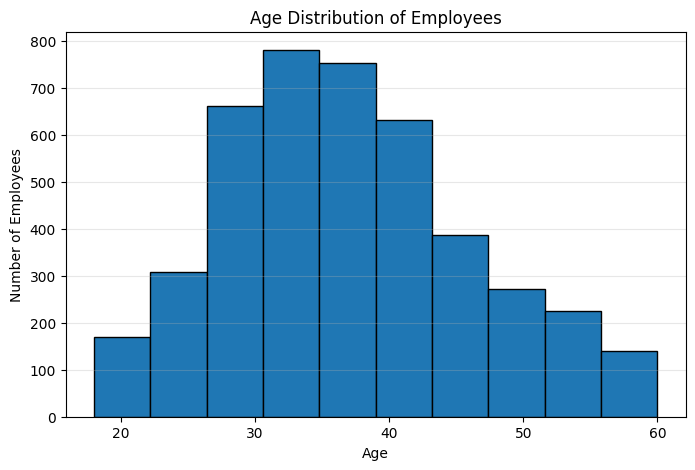

In [3]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Age'],
    bins=10,
    edgecolor='black'
)

plt.title("Age Distribution of Employees")

plt.xlabel("Age")

plt.ylabel("Number of Employees")

plt.grid(axis='y', alpha=0.3)

plt.show()

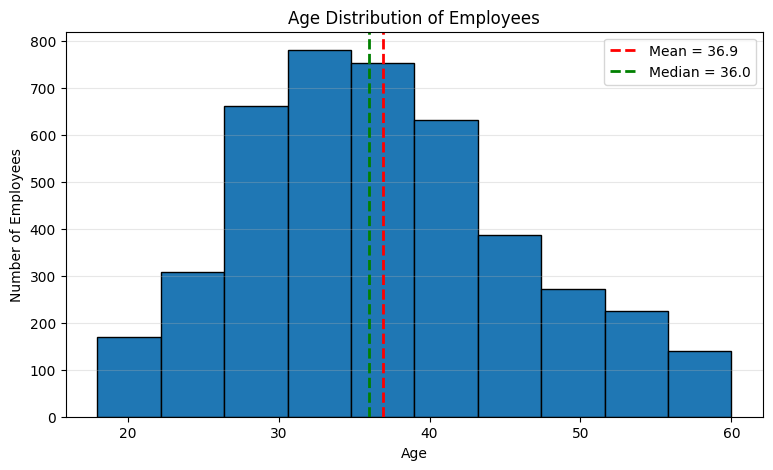

In [4]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()

plt.figure(figsize=(9,5))

plt.hist(
    df['Age'],
    bins=10,
    edgecolor='black'
)

plt.axvline(mean_age,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f"Mean = {mean_age:.1f}")

plt.axvline(median_age,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f"Median = {median_age:.1f}")

plt.title("Age Distribution of Employees")

plt.xlabel("Age")

plt.ylabel("Number of Employees")

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

In [5]:
df['MonthlyIncome'].describe()

count      4327.000000
mean      65029.244280
std       46976.222828
min       10090.000000
25%       29260.000000
50%       49360.000000
75%       83805.000000
max      199990.000000
Name: MonthlyIncome, dtype: float64

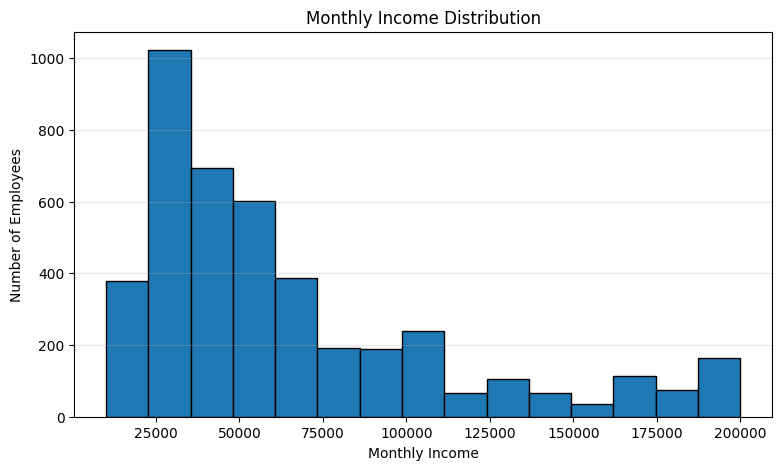

In [6]:
plt.figure(figsize=(9,5))

plt.hist(
    df['MonthlyIncome'],
    bins=15,
    edgecolor='black'
)

plt.title("Monthly Income Distribution")

plt.xlabel("Monthly Income")

plt.ylabel("Number of Employees")

plt.grid(axis='y', alpha=0.3)

plt.show()

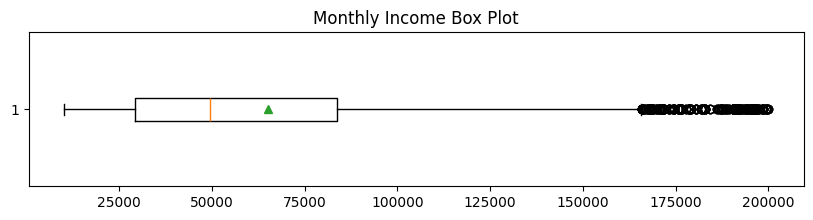

In [29]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df['MonthlyIncome'],
    vert=False,
    showmeans=True
)

plt.title("Monthly Income Box Plot")

plt.show()

In [8]:
df['Department'].value_counts()

Department
Research & Development    2824
Sales                     1315
Human Resources            188
Name: count, dtype: int64

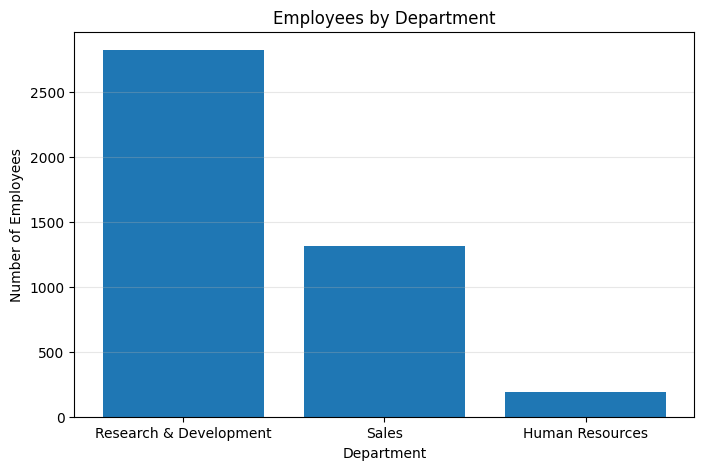

In [9]:
dept_count = df['Department'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    dept_count.index,
    dept_count.values
)

plt.title("Employees by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.grid(axis='y', alpha=0.3)

plt.show()

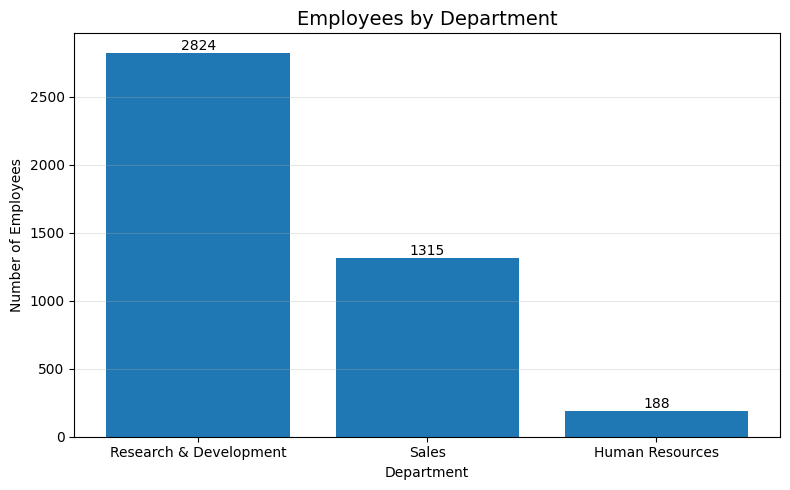

In [10]:
dept_count = df['Department'].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(
    dept_count.index,
    dept_count.values
)

# Add value labels on top of bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        int(bar.get_height()),
        ha='center'
    )

plt.title("Employees by Department", fontsize=14)

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
role_count = df['JobRole'].value_counts().sort_index()

print(role_count)

JobRole
Healthcare Representative    381
Human Resources              154
Laboratory Technician        760
Manager                      300
Manufacturing Director       428
Research Director            238
Research Scientist           863
Sales Executive              959
Sales Representative         244
Name: count, dtype: int64


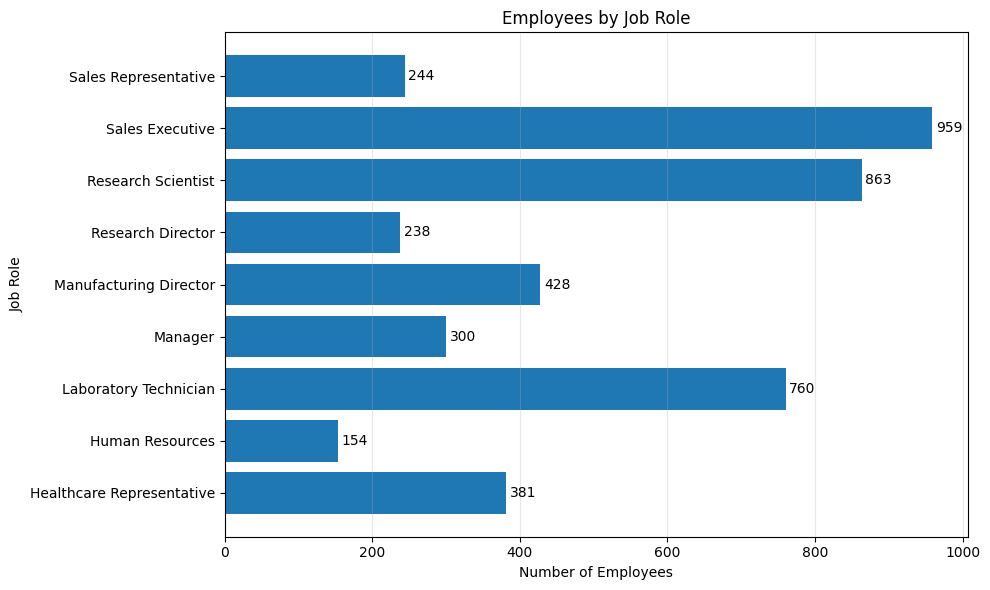

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    role_count.index,
    role_count.values
)
for bar in bars:
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
       f"{int(bar.get_width())}",
        va='center'
    )


plt.title("Employees by Job Role")

plt.xlabel("Number of Employees")

plt.ylabel("Job Role")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

plt.show()

In [17]:
pd.crosstab(
    df['Department'],
    df['Attrition']
)

Attrition,No,Yes
Department,,
Human Resources,132,56
Research & Development,2377,447
Sales,1117,198


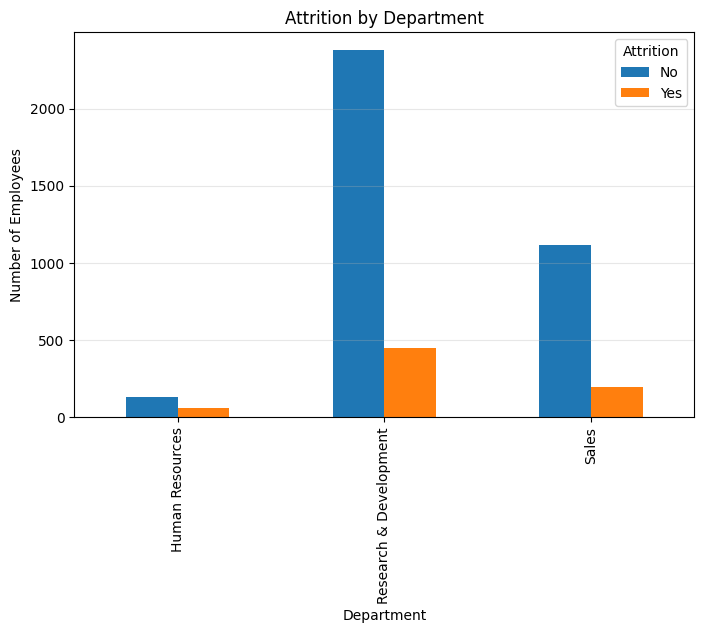

In [18]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

dept_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Attrition by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [19]:
dept_attrition_rate = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100
#normalizes wrt index 
print(dept_attrition_rate.round(2))

Attrition                  No    Yes
Department                          
Human Resources         70.21  29.79
Research & Development  84.17  15.83
Sales                   84.94  15.06


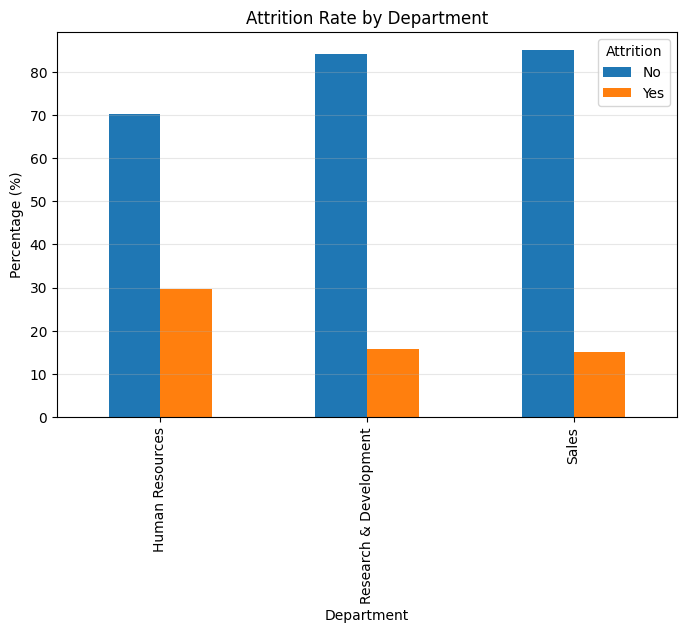

In [20]:
dept_attrition_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")

plt.xlabel("Department")

plt.ylabel("Percentage (%)")

plt.grid(axis='y', alpha=0.3)

plt.show()

In [21]:
df.groupby('Department')['MonthlyIncome'].mean()

Department
Human Resources           57916.595745
Research & Development    67240.293909
Sales                     61297.817490
Name: MonthlyIncome, dtype: float64

In [22]:
df.groupby('Department')['MonthlyIncome'].agg(
    ['count', 'mean', 'min', 'max']
)

,count,mean,min,max
Department,,,,
Human Resources,188,57916.595745,13930,190810
Research & Development,2824,67240.293909,10510,199990
Sales,1315,61297.817490,10090,198590


In [23]:
corr_matrix = df.select_dtypes(include='number').corr()

corr_matrix

,Age,DistanceFromHome,Education,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,OverallSatisfaction,IncomePerJobLevel
Age,1.000000,0.004038,-0.036293,0.004105,-0.002553,-0.046365,0.303149,-0.034825,-0.030797,0.681540,-0.030548,0.314413,0.217410,0.204564,0.008571,-0.000305,-0.024180,0.019008,-0.025690,-0.004728,-0.039019
DistanceFromHome,0.004038,1.000000,-0.007594,0.002109,-0.035861,-0.018530,-0.014806,0.036777,0.009745,0.004214,-0.007789,0.030769,0.001802,0.019971,0.018003,-0.010282,0.007716,-0.006985,0.036165,0.008098,0.002945
Education,-0.036293,-0.007594,1.000000,-0.012357,0.043622,0.005492,-0.018113,-0.043034,-0.000674,-0.009849,0.009832,0.008329,0.025966,0.007149,-0.045592,-0.005037,-0.005097,-0.019821,-0.035468,-0.034598,-0.038103
EmployeeID,0.004105,0.002109,-0.012357,1.000000,-0.002887,0.008683,-0.001450,-0.003733,-0.012918,-0.003069,-0.009300,-0.000820,0.001527,0.004594,0.001418,0.000460,-0.004519,0.008263,-0.008082,-0.000668,0.004419
JobLevel,-0.002553,-0.035861,0.043622,-0.002887,1.000000,0.045665,-0.008701,0.010213,0.003552,-0.035876,-0.033043,-0.064995,-0.059751,-0.055142,-0.023323,-0.019188,-0.024461,-0.013534,-0.002066,-0.037494,-0.441452
MonthlyIncome,-0.046365,-0.018530,0.005492,0.008683,0.045665,1.000000,-0.019222,0.008337,0.034060,-0.029148,0.044899,0.002913,0.064142,0.026816,-0.004850,0.003660,0.003822,0.028641,0.020848,0.000840,0.760413
NumCompaniesWorked,0.303149,-0.014806,-0.018113,-0.001450,-0.008701,-0.019222,1.000000,0.031006,0.016746,0.239518,-0.030412,-0.114949,-0.033946,-0.107127,0.012688,-0.058442,-0.008502,0.026364,0.019987,-0.033152,-0.025232
PercentSalaryHike,-0.034825,0.036777,-0.043034,-0.003733,0.010213,0.008337,0.031006,1.000000,0.012795,-0.021559,-0.035239,-0.027938,-0.029224,-0.040741,-0.003544,0.035805,-0.040749,-0.003950,0.773872,0.003965,0.002594
StockOptionLevel,-0.030797,0.009745,-0.000674,-0.012918,0.003552,0.034060,0.016746,0.012795,1.000000,0.000131,-0.068245,0.007328,0.019142,0.015888,-0.006106,0.038818,-0.024070,0.008173,-0.037210,0.011186,0.014132
TotalWorkingYears,0.681540,0.004214,-0.009849,-0.003069,-0.035876,-0.029148,0.239518,-0.021559,0.000131,1.000000,-0.041068,0.632626,0.407035,0.463261,-0.002813,-0.014568,-0.001011,0.003694,-0.002640,-0.011636,-0.009315


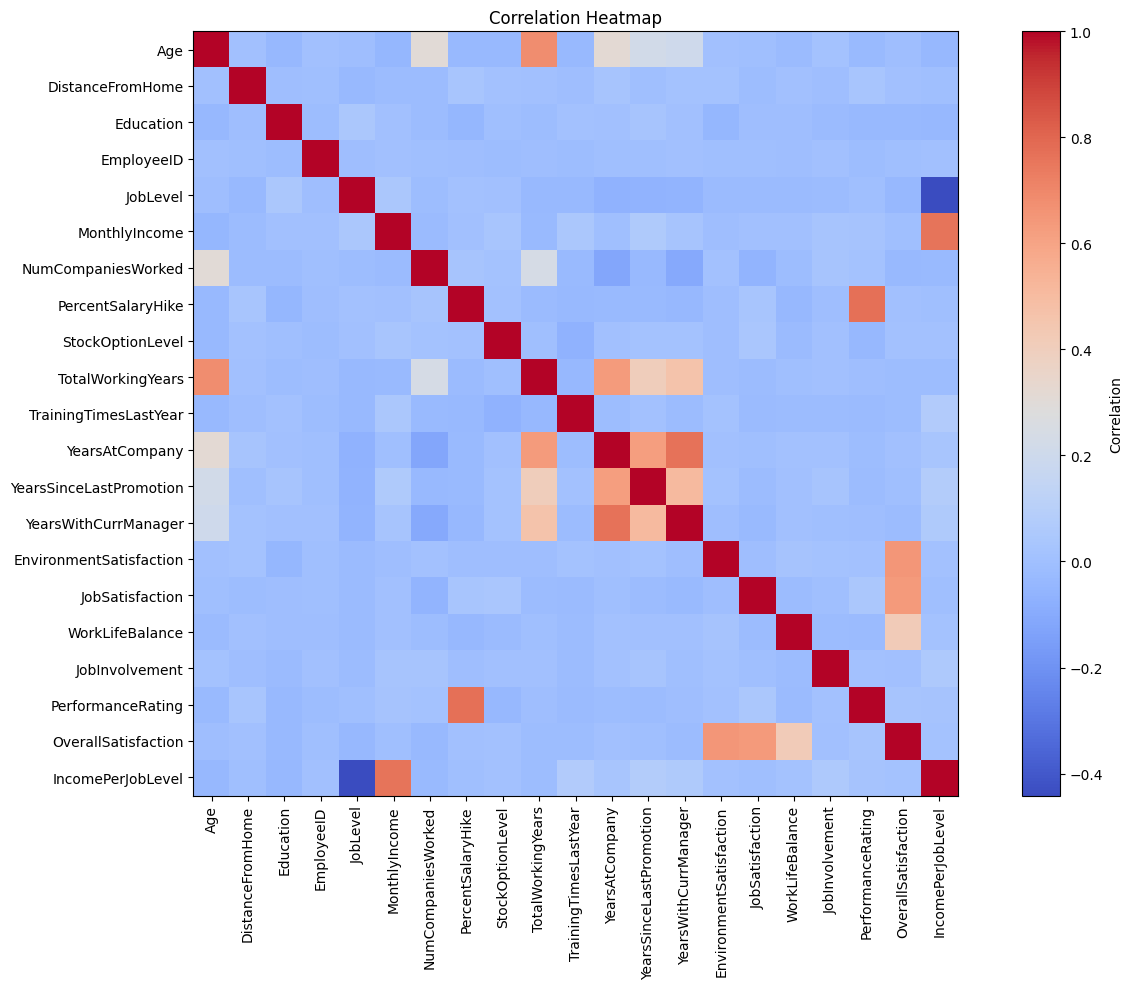

In [25]:
plt.figure(figsize=(14,10))

plt.imshow(corr_matrix, cmap='coolwarm')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

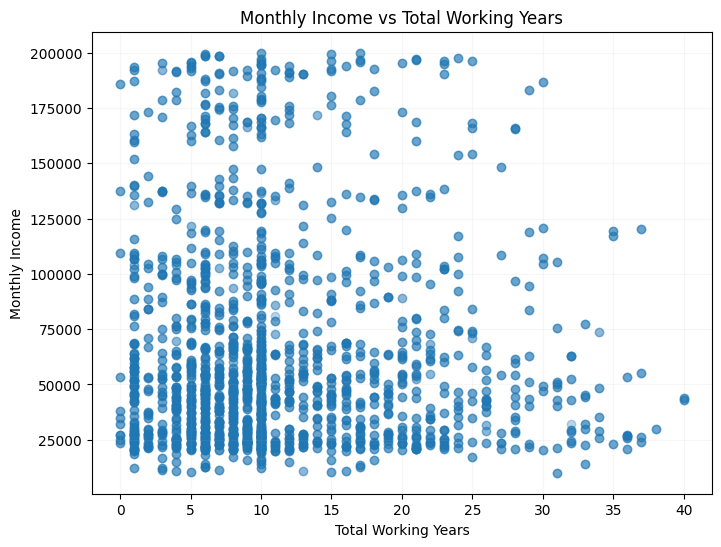

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['TotalWorkingYears'],
    df['MonthlyIncome'],
    alpha=0.3
)

plt.title("Monthly Income vs Total Working Years")

plt.xlabel("Total Working Years")

plt.ylabel("Monthly Income")

plt.grid(alpha=0.1)

plt.show()